# Drift Simulation

Assuming we only train on 2002 to 2017, how many timesteps will it take for each of the models to drift from an acceptable range?

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ERCOTProcessor
import WeatherProcessing
import FeatureEngineering
import ForecastingHelpers
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

In [2]:
drift_df = ERCOTProcessor.fileprocessing(2016,2024)

/home/lambpc/PowerSim_AMARANTH/ElectricityDemandAustinTX/LoadForecastingAttacks/ERCOTProcessor.py:21: FutureWarning: Parsed string "11/05/2017 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
/home/lambpc/PowerSim_AMARANTH/ElectricityDemandAustinTX/LoadForecastingAttacks/ERCOTProcessor.py:21: FutureWarning: Parsed string "11/04/2018 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
/home/lambpc/PowerSim_AMARANTH/ElectricityDemandAustinTX/LoadForecastingAttacks/ERCOTProcessor.py:21: FutureWa

In [3]:
drift_df.head()

,load
time,
2016-01-01 00:00:00,5479.057816
2016-01-01 01:00:00,5405.955778
2016-01-01 02:00:00,5334.159606
2016-01-01 03:00:00,5302.938201
2016-01-01 04:00:00,5364.298843


In [4]:
full_data = pd.read_csv("../4049454.csv")
data17t024 = WeatherProcessing.getData(full_data, 2016, 2024)

/var/tmp/pbs.4593358.sawtoothpbs/ipykernel_18142/4102368585.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  full_data = pd.read_csv("../4049454.csv")


In [5]:
unprocessed_data = pd.read_csv("weather_data_2016to2024.csv")
unprocessed_data['DATE'] = pd.to_datetime(unprocessed_data['DATE'])
unprocessed_data.dropna(inplace=True)
WeatherProcessing.all_years(unprocessed_data, list(range(2016,2024)), 'weather_20162024.csv')

In [6]:
filename = 'weather_20162024.csv'
weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
weather_df = weather_df.set_index('time')
weather_df.head()

/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/pandas/core/indexes/base.py:7616: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,temp,humd,wnsp,cond
time,,,,
2016-01-01 04:00:00,45.0,0.68,13.0,3.0
2016-01-02 15:00:00,46.0,0.63,0.0,3.0
2016-01-02 16:00:00,46.0,0.68,0.0,3.0
2016-01-02 17:00:00,44.0,0.85,0.0,3.0
2016-01-02 18:00:00,44.0,0.89,0.0,3.0


In [7]:
drift_norm = FeatureEngineering.feature_engineering(weather_df, drift_df)

Retrieve training data

In [8]:
filename = '../Weather_data_all.csv'
weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
weather_df = weather_df.set_index('time')
weather_df.head()

/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/pandas/core/indexes/base.py:7616: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,temp,humd,wnsp,cond
time,,,,
2002-01-01 00:00:00,36.0,0.64,7.0,0.0
2002-01-01 01:00:00,36.0,0.57,8.0,0.0
2002-01-01 02:00:00,36.0,0.57,8.0,0.0
2002-01-01 03:00:00,36.0,0.57,6.0,0.0
2002-01-01 04:00:00,35.0,0.61,8.0,0.0


In [9]:
norm_df = ERCOTProcessor.fileprocessing(2002,2018)

/home/lambpc/PowerSim_AMARANTH/ElectricityDemandAustinTX/LoadForecastingAttacks/ERCOTProcessor.py:71: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ercot_df = ercot_df.asfreq('H', method='pad')


In [10]:
df_norm = FeatureEngineering.feature_engineering(weather_df, norm_df)

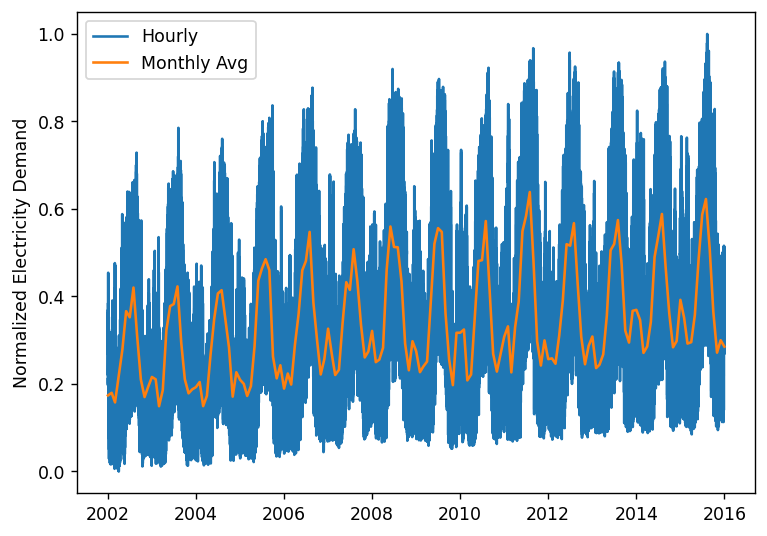

In [11]:
monthly_norm = df_norm['load'].resample('MS').mean().bfill()
plt.plot(df_norm['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

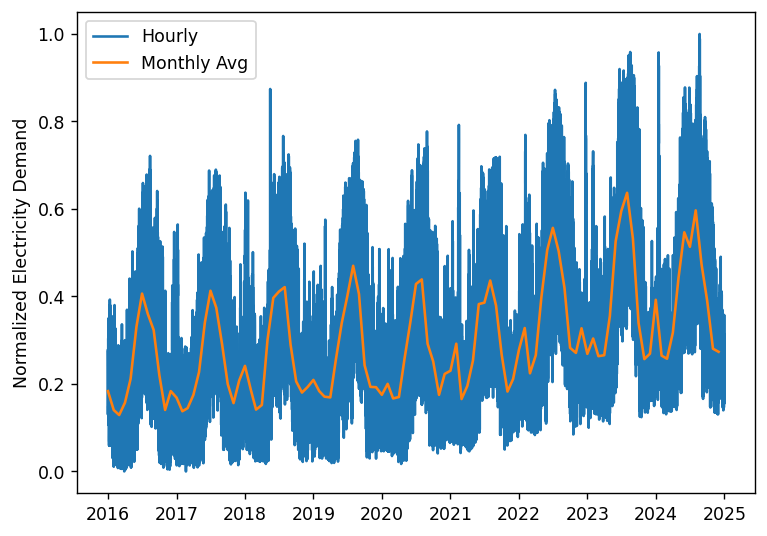

In [12]:
monthly_norm_drift = drift_norm['load'].resample('MS').mean().bfill()
plt.plot(drift_norm['load'], label='Hourly')
plt.plot(monthly_norm_drift, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [13]:
norms_monthly = pd.concat([monthly_norm, monthly_norm_drift])

In [14]:
norms_hourly = pd.concat([df_norm, drift_norm])

In [15]:
norms_hourly = norms_hourly.drop_duplicates(subset=None, keep="last", inplace=False)

In [16]:
norms_hourly = norms_hourly[~norms_hourly.index.duplicated()]

In [17]:
norms_monthly = norms_monthly[~norms_monthly.index.duplicated()]

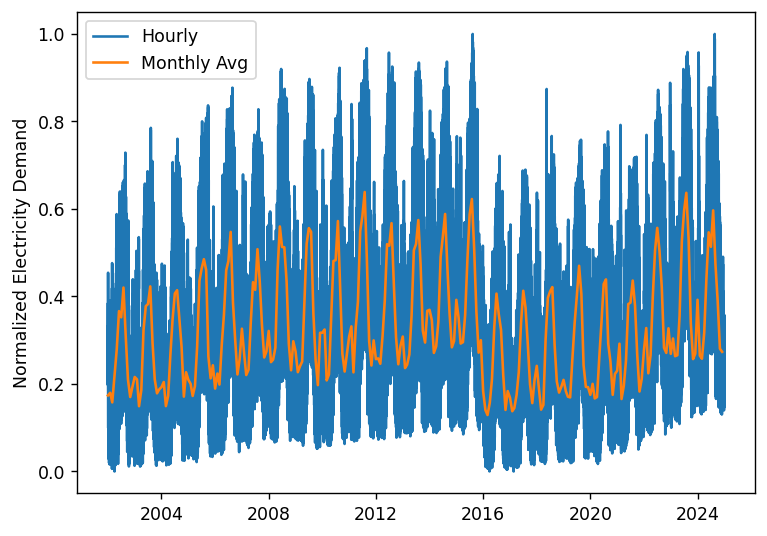

In [18]:
normed_norms = norms_hourly['load'].resample('MS').mean().bfill()
plt.plot(norms_hourly['load'], label='Hourly')
plt.plot(normed_norms, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [19]:
# Trained on 2002 to 2017, tested on 2017-2024
train, validate, test = FeatureEngineering.train_test_split(norms_monthly, 2014, 2015, 2016, 2017)

## SARIMA

In [20]:
import sarima_modeling

search = sarima_modeling.grid_search(train, validate)

time
2002-01-01    0.173749
2002-02-01    0.179793
2002-03-01    0.157879
2002-04-01    0.219560
2002-05-01    0.278807
Name: load, dtype: float64
    p  d  q  P  D  Q       mae
18  0  1  0  0  1  0  0.054906


In [21]:
model_sarima, sarima_forec, sarima_pred, sarima_ci = sarima_modeling.sarima(train, validate, 1, 1, 1, 0, 1, 1)

Data up to 2016 (training + validation)

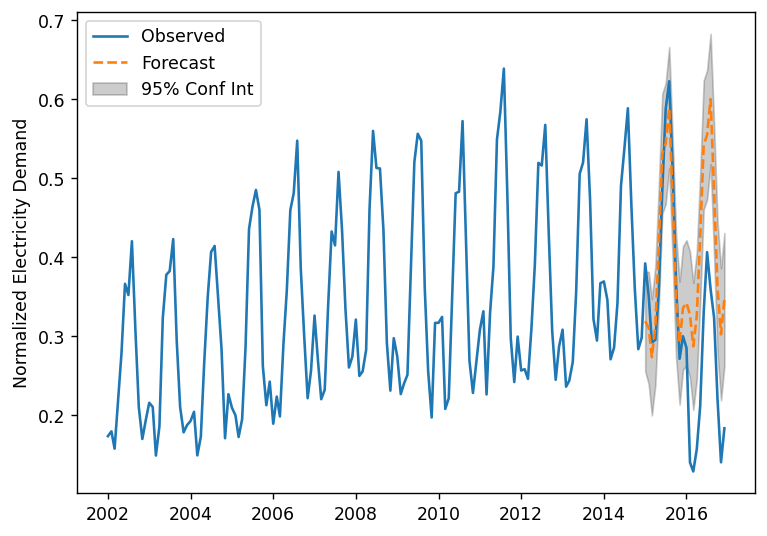

In [22]:
# plotting
plt.plot(norms_monthly[:'2016'], label='Observed')
plt.plot(sarima_pred, label='Forecast', ls='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% Conf Int')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [23]:
train_2 = pd.concat([train, validate])

Data 2017 and beyond

In [24]:
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(train_2, test, 1, 1, 1, 0, 1, 1)

In [25]:
test

time
2017-01-01    0.168757
2017-02-01    0.137659
2017-03-01    0.144771
2017-04-01    0.175150
2017-05-01    0.227309
                ...   
2024-08-01    0.596805
2024-09-01    0.473795
2024-10-01    0.390313
2024-11-01    0.280578
2024-12-01    0.273501
Name: load, Length: 96, dtype: float64

In [26]:
drift_ci.set_index(test.index, inplace=True)

In [27]:
preds = pd.concat([sarima_pred, drift_pred])

In [28]:
ci = pd.concat([sarima_ci, drift_ci])

Find where the prediction and the true power start deviating to come up with a "lifespan" of the model prior to retraining. The blackline represents where the division happens where the model falls out of 95% confidence.

In [29]:
for i, index_label in enumerate(drift_ci.index):
        lb = drift_ci.iloc[i,0]
        ub = drift_ci.iloc[i,1]
        c_x = sarima_ci.iloc[-1,1]-sarima_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds[i]
            break
        else:
            div = ci.index[-1]

In [30]:
div

Timestamp('2017-02-01 00:00:00')

If there is no significant deviation from 95% confidence interval, div is at the end of the graph.

To get our "PF" we can calculate it by the deviation of the model from when it first did predictions to the black line.

Over a year after training which means the model can be retrained in a reasonable amount of time... Lets calculate the divergence overtime.

In [31]:
pk,qk,H,M,D = ForecastingHelpers.calculateEntropy(norms_monthly, preds, 2023)
print("Normal entropy: " + str(H) + " Predicted entropy: " + str(M) + " Relative Entropy: " + str(D))

Normal entropy: 1.9998802534700455 Predicted entropy: -inf Relative Entropy: inf


In [32]:
diverge = ForecastingHelpers.calculateKLDivergence(norms_monthly,preds)

Low drift <= 0.1, Moderate drift <= 0.25, Significant drift > 0.25

https://link.springer.com/article/10.1007/s42488-024-00119-y

In [33]:
low_drift, med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, test)

In [34]:
diverge[test.index[0]:].index[np.argmax(diverge[test.index[0]:]<=0.1)]

Timestamp('2017-01-01 00:00:00')

In [35]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(preds, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(preds, med_drift)))

Exceeds confidence interval: 762 days 00:00:00 Exceeds 0.1 divergence: 1886 days 00:00:00


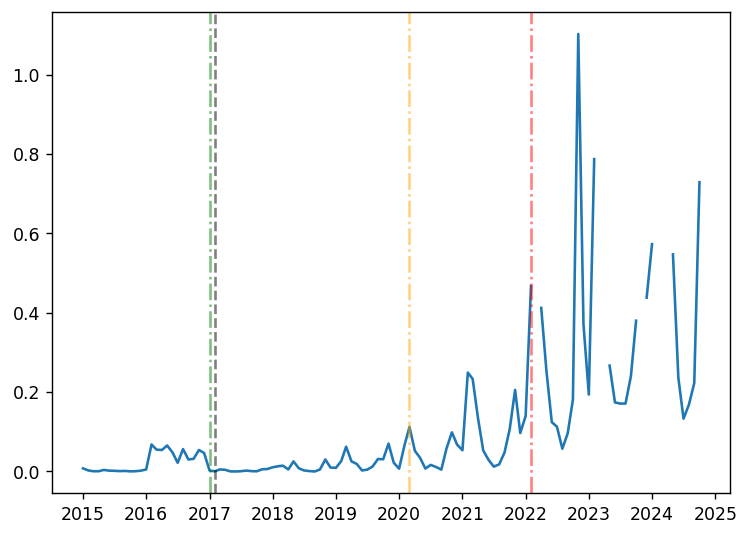

In [36]:
import matplotlib.pyplot as plt
plt.plot(diverge)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")

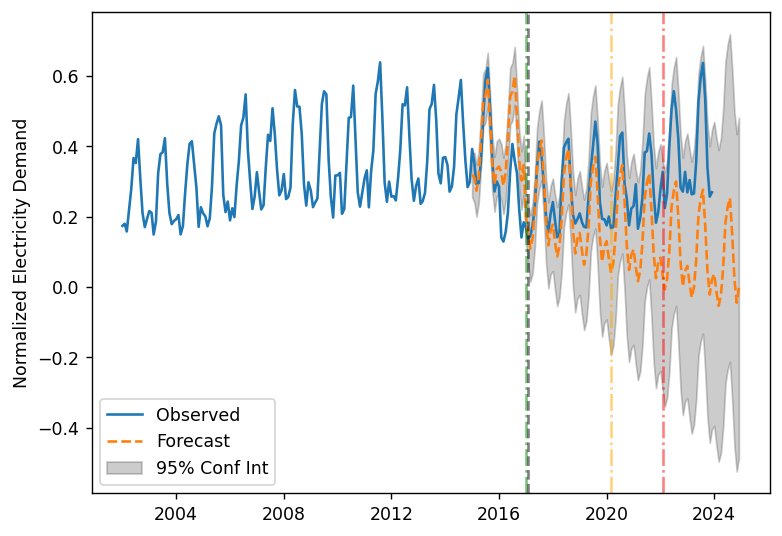

In [37]:
# plotting
plt.plot(norms_monthly[:'2023'], label='Observed')
plt.plot(preds, label='Forecast', ls='--')
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% Conf Int')
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

KL divergence increases prior to the divergence point which can assist with determining when drift occurs. 

## Linear Regression

In [38]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(norms_hourly)

In [39]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

In [40]:
from sklearn.linear_model import LinearRegression
mod_lr = LinearRegression()
mod_lr.fit(X_tr, y_tr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
from mapie.regression import MapieRegressor

mapie = MapieRegressor(mod_lr, method="naive")

In [42]:
mapie.fit(X_tr, y_tr)

,estimator,LinearRegression()
,method,'naive'
,cv,None
,test_size,None
,n_jobs,None
,agg_function,'mean'
,verbose,0
,conformity_score,None
,random_state,None
,fit_intercept,True
,copy_X,True


In [43]:
import ForecastingHelpers
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie, exog_val, y_init_val, 0.05)

In [44]:
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])

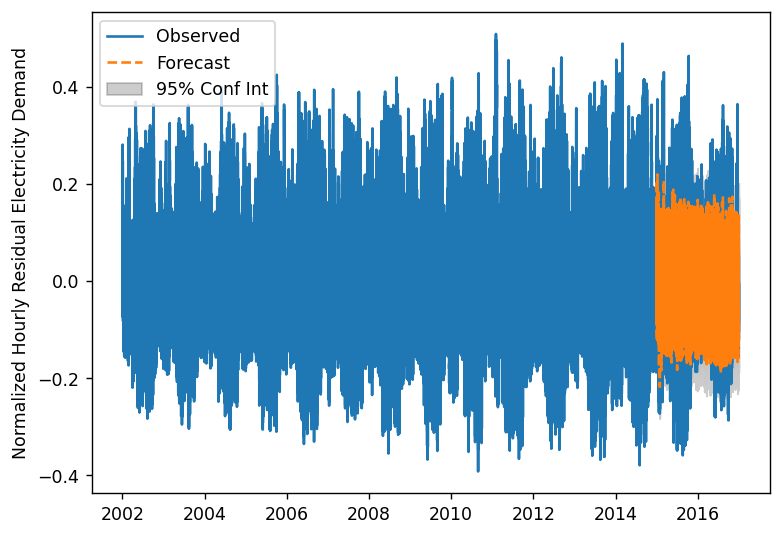

In [45]:
ForecastingHelpers.plot_full(yp_full, pred_mapie, yp_val.index, pred_ci)

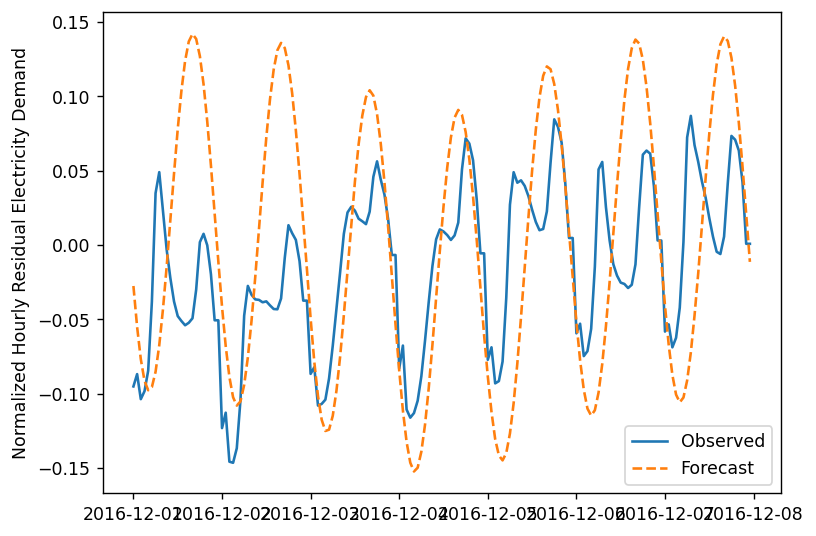

In [46]:
plt.plot(yp_full['2016-12-01':'2016-12-07'], label='Observed')
plt.plot(pred_df['2016-12-01':'2016-12-07'], label='Forecast', ls='--')
plt.ylabel('Normalized Hourly Residual Electricity Demand')
plt.legend()

Now for the testing

In [47]:
pred_mapie_te, pred_ci_te = ForecastingHelpers.weekly_forecast(yp_te.index, mapie, exog_te, y_init_te, 0.05)

In [48]:
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])

In [49]:
pred_ci_te.set_index(test.index, inplace=True)

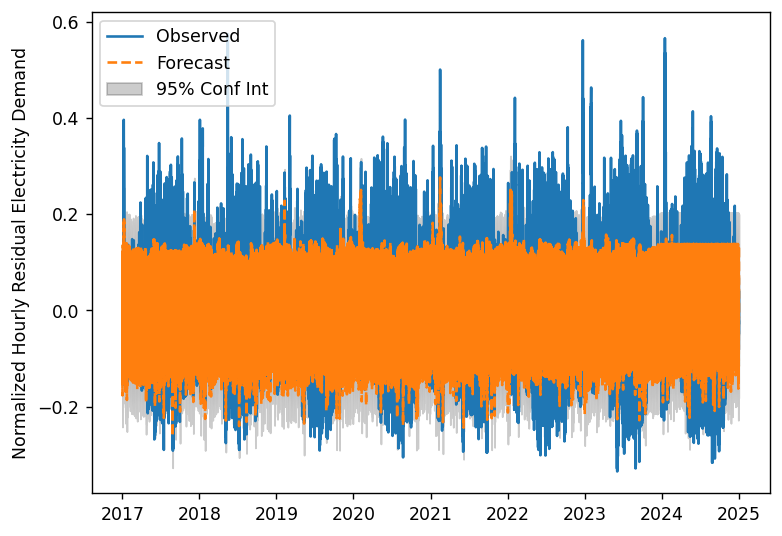

In [50]:
ForecastingHelpers.plot_full(yp_te, pred_mapie_te, yp_te.index, pred_ci_te)

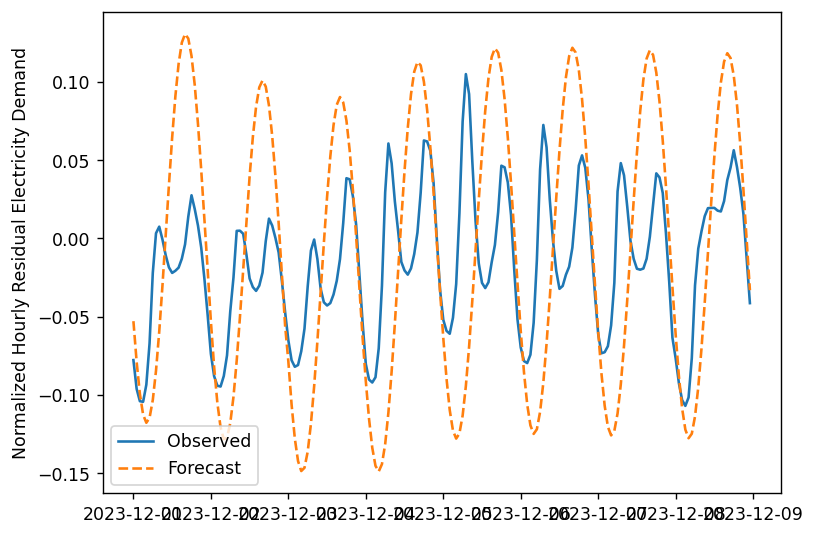

In [51]:
# Plotting in 2023
plt.plot(yp_te['2023-12-01':'2023-12-08'], label='Observed')
plt.plot(pred_test['2023-12-01':'2023-12-08'], label='Forecast', ls='--')
plt.ylabel('Normalized Hourly Residual Electricity Demand')
plt.legend()

In [52]:
preds_lr = pd.concat([pred_df, pred_test])
ci = pd.concat([pred_ci, pred_ci_te])

In [53]:
normals = pd.concat([yp_val, yp_te])
pred_np = preds_lr['load']

In [54]:
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = pred_np[i]
            break
        else:
            div = ci.index[-1]

In [55]:
div

Timestamp('2017-01-01 00:00:00')

In [56]:
ForecastingHelpers.MTTF(preds_lr, div)

Timedelta('731 days 00:00:00')

In [57]:
monthly_norms = normals.resample('MS').mean().bfill()
monthly_pred = preds_lr['load'].resample('MS').mean().bfill()

In [58]:
pk,qk,H,M,D = ForecastingHelpers.calculateEntropy(monthly_norms, monthly_pred, 2023)
print("Normal entropy: " + str(H) + " Predicted entropy: " + str(M) + " Relative Entropy: " + str(D))

Normal entropy: -inf Predicted entropy: -inf Relative Entropy: inf


In [59]:
diverge = ForecastingHelpers.calculateKLDivergence(normals, pred_np)

In [60]:
low_drift, med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, test)

In [61]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(preds_lr, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(preds_lr, med_drift)))

Exceeds confidence interval: 731 days 00:00:00 Exceeds 0.1 divergence: 731 days 00:00:00


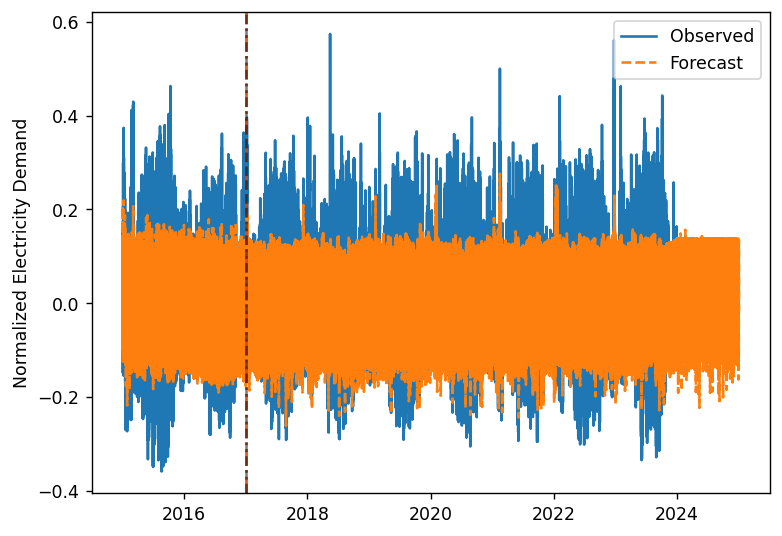

In [62]:
# plotting
plt.plot(normals[:'2023'], label='Observed')
plt.plot(preds_lr, label='Forecast', ls='--')
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [63]:
diverge_mo = ForecastingHelpers.calculateKLDivergence(monthly_norms, monthly_pred)

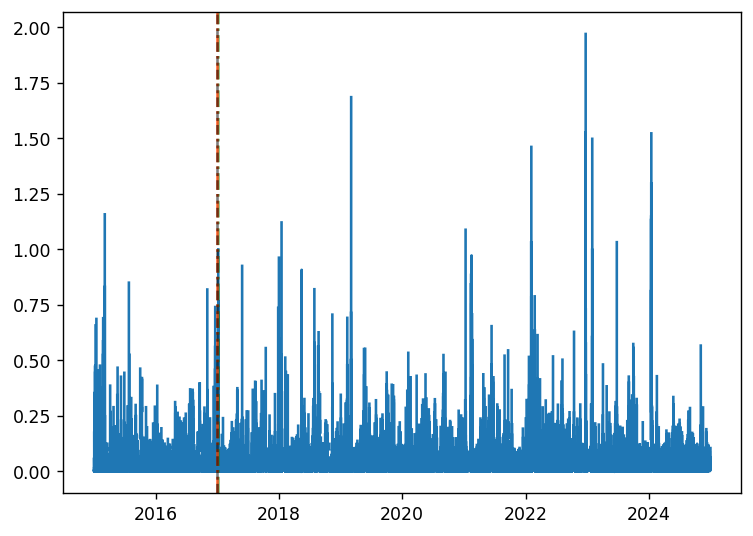

In [64]:
plt.plot(diverge)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")

## Gradient Boosted Regression

In [65]:
def compute_mae(y, yhat):
    """given predicted and observed values, computes mean absolute error"""
    return np.mean(np.abs(yhat - y))

def forecast(model, exog, y_init):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = model.predict(Xi_te)[0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat.append(model.predict(Xi_te)[0])
    return np.array(yhat)
def weekly_forecast(model, exog, y_init):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        yhat.append(forecast(model, exog_i, yi))
    return np.hstack(yhat)

In [66]:
from sklearn.ensemble import GradientBoostingRegressor

# train GBR model, and get validation set performance
def get_gbr_mae(lr, ne, md):
    mod = GradientBoostingRegressor(learning_rate=lr, n_estimators=ne, max_depth=md)
    mod.fit(X_tr, y_tr)
    pred_val = weekly_forecast(mod, exog_val, y_init_val)
    return compute_mae(y_val, pred_val)

# define potential sets of hyperparameters
learning_rate = [0.01, 0.1, 1.]
n_estimators = [100, 500, 1000]
max_depth = [2, 3, 4]
grid_search = pd.DataFrame(columns=['lr','ne','md','mae'])

# perform grid search
for lr in learning_rate:    
    for ne in n_estimators:        
        for md in max_depth:            
            mae = get_gbr_mae(lr, ne, md)
            params = {'lr':lr, 'ne':ne, 'md':md, 'mae':mae} 
            params_df = pd.DataFrame([params])
            grid_search = pd.concat([grid_search, params_df], ignore_index=True)

# display best hyperparameters based on grid search
grid_gbr = grid_search.sort_values('mae').head(1)

In [67]:
from sklearn.ensemble import GradientBoostingRegressor
from mapie.regression import MapieRegressor

# best hyperparameters
lr, ne, md = grid_gbr['lr'].values[0], grid_gbr['ne'].values[0], grid_gbr['md'].values[0]

# train model and get predictions
mod_gbr = GradientBoostingRegressor(learning_rate=lr, n_estimators=ne, max_depth=md)
mod_gbr.fit(X_tr, y_tr)

mapie = MapieRegressor(mod_gbr, method="naive")
mapie.fit(X_tr, y_tr)
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie, exog_val, y_init_val, 0.05)

In [68]:
pred_mapie_te, pred_ci_te = ForecastingHelpers.weekly_forecast(yp_te.index, mapie, exog_te, y_init_te, 0.05)

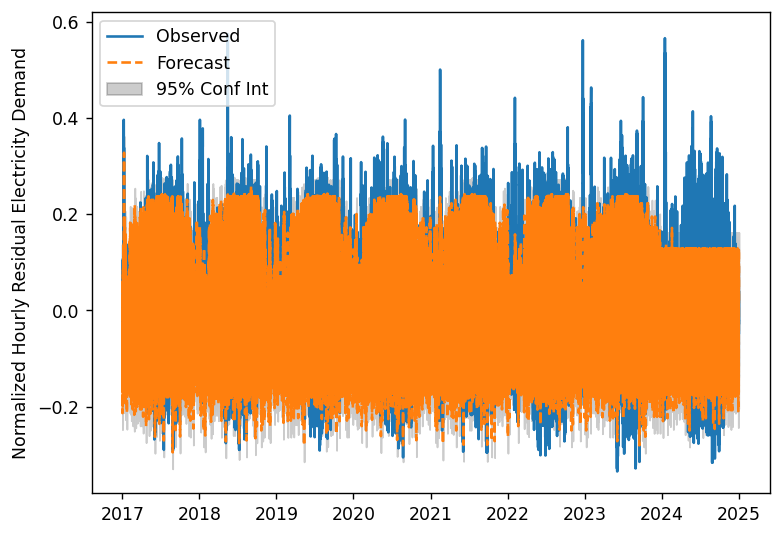

In [69]:
ForecastingHelpers.plot_full(yp_te, pred_mapie_te, yp_te.index, pred_ci_te)

In [70]:
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])

In [71]:
preds_gbr = pd.concat([pred_df, pred_test])
ci = pd.concat([pred_ci, pred_ci_te])

In [72]:
preds_np = preds_gbr['load']

In [73]:
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = ci.index[-1]

In [74]:
div

Timestamp('2017-01-02 07:00:00')

In [75]:
ForecastingHelpers.MTTF(preds_gbr, div)

Timedelta('732 days 07:00:00')

In [76]:
pk,qk,H,M,D = ForecastingHelpers.calculateEntropy(normals, preds_gbr['load'], 2023)
print("Normal entropy: " + str(H) + " Predicted entropy: " + str(M) + " Relative Entropy: " + str(D))

Normal entropy: -inf Predicted entropy: -inf Relative Entropy: inf


In [77]:
diverge = ForecastingHelpers.calculateKLDivergence(normals,preds_np)

In [78]:
low_drift, med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)

In [79]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(pred_df, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(pred_df, med_drift)))

Exceeds confidence interval: 732 days 07:00:00 Exceeds 0.1 divergence: 731 days 00:00:00


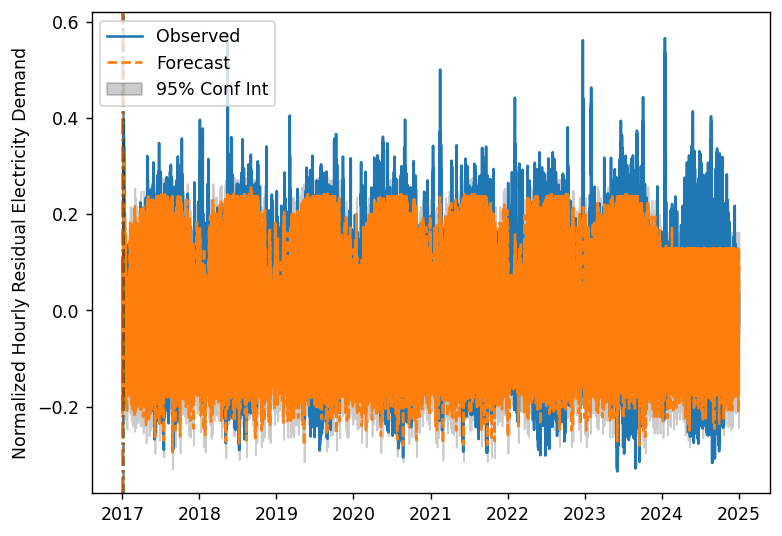

In [80]:
ForecastingHelpers.plot_full_w_div(yp_te, pred_mapie_te, yp_te.index, pred_ci_te, div)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")

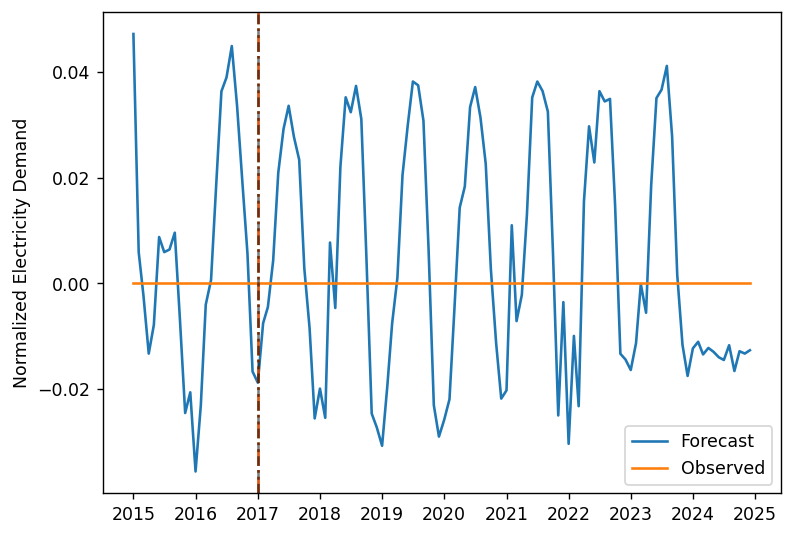

In [81]:
monthly_norms = normals.resample('MS').mean().bfill()
monthly_pred = preds_gbr['load'].resample('MS').mean().bfill()

plt.plot(monthly_pred, label='Forecast')
plt.plot(monthly_norms, label='Observed')
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

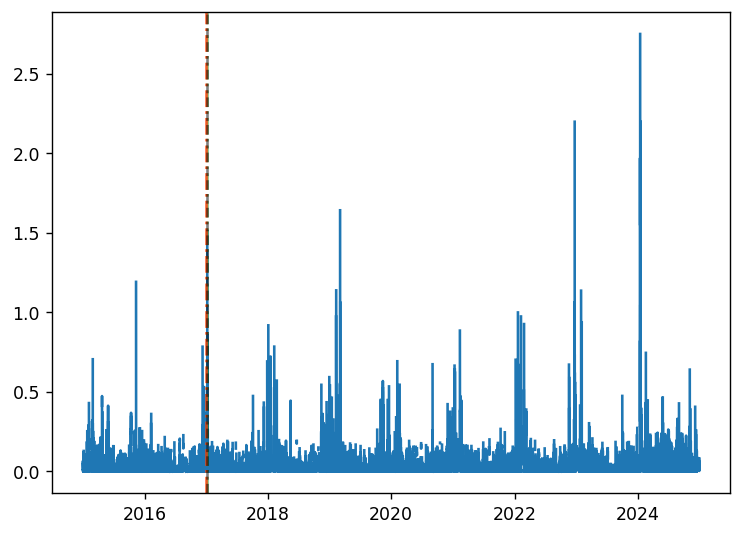

In [82]:
plt.plot(diverge)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")

In [83]:
diverge_mo = ForecastingHelpers.calculateKLDivergence(monthly_norms, monthly_pred)

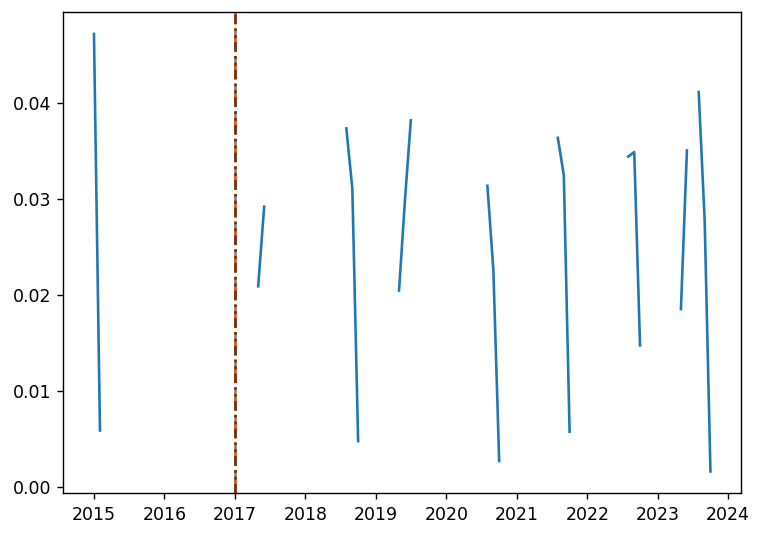

In [84]:
plt.plot(diverge_mo)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")

## MLP Regression

In [85]:
from sklearn.neural_network import MLPRegressor

# train MLP model, and get validation set performance
def get_mlp_mae(hl, a, lr, mi):
    mod = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
    mod.fit(X_tr, y_tr)
    pred_val = weekly_forecast(mod, exog_val, y_init_val)
    return compute_mae(y_val, pred_val)

# define potential sets of hyperparameters
hidden_layer_sizes = [(100,),(500,),(100,10,),(100,100,)]
alpha = [0.0001, 0.00001, 0.001]
learning_rate = [0.0001, 0.001, 0.01]
max_iter = [200, 1000, 10000]
grid_search = pd.DataFrame(columns=['hl','a','lr','mi','mae'])

# perform grid search
for hl in hidden_layer_sizes:    
    for a in alpha:        
        for lr in learning_rate:
            for mi in max_iter:
                mae = get_mlp_mae(hl, a, lr, mi)
                params = {'hl':hl, 'a':a, 'lr':lr, 'mi':mi, 'mae':mae} 
                params_df = pd.DataFrame([params])
                grid_search = pd.concat([grid_search, params_df], ignore_index=True)

# display best hyperparameters based on grid search
grid_mlp = grid_search.sort_values('mae').head(1)

In [86]:
from sklearn.neural_network import MLPRegressor
# best hyperparamters
hl, a, lr, mi  = grid_mlp['hl'].values[0], grid_mlp['a'].values[0], grid_mlp['lr'].values[0], grid_mlp['mi'].values[0]

# train model and get predictions
mod_mlp = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
mod_mlp.fit(X_tr, y_tr)

mapie_mlp = MapieRegressor(mod_mlp, method="naive")
mapie_mlp.fit(X_tr, y_tr)
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie_mlp, exog_val, y_init_val, 0.05)

In [87]:
pred_mapie_te, pred_ci_te = ForecastingHelpers.weekly_forecast(yp_te.index, mapie_mlp, exog_te, y_init_te, 0.05)

In [88]:
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])

In [89]:
preds_mlp = pd.concat([pred_df, pred_test])
ci = pd.concat([pred_ci, pred_ci_te])

In [90]:
preds_np = preds_mlp['load']

In [91]:
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = ci.index[-1]

MAE: 0.07481052503229159


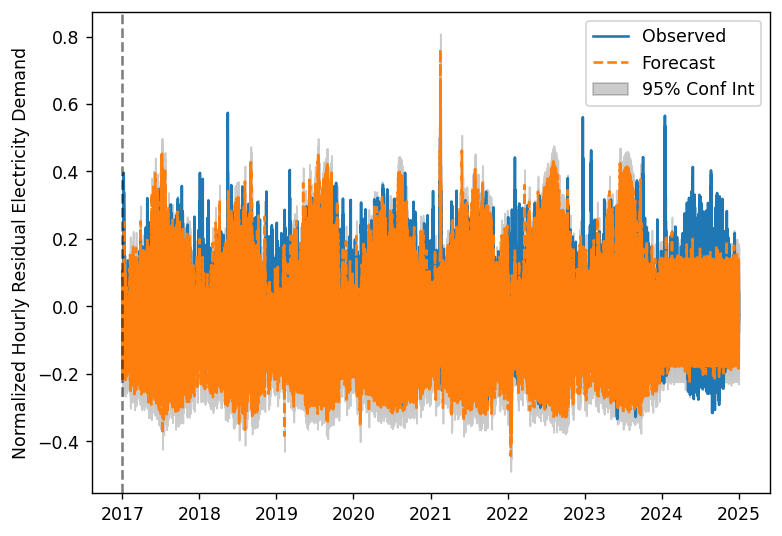

In [92]:
# compute error, and plot on both long and short time scales
print('MAE:', ForecastingHelpers.compute_mae(y_val, pred_mapie))
ForecastingHelpers.plot_full_w_div(yp_te, pred_mapie_te, yp_te.index, pred_ci_te, div)
#ForecastingHelpers.plot_week(yp_full, pred_mapie, yp_val.index)

In [93]:
ForecastingHelpers.MTTF(preds_mlp, div)

Timedelta('731 days 03:00:00')

In [94]:
pk,qk,H,M,D = ForecastingHelpers.calculateEntropy(normals, preds_mlp['load'], 2023)
print("Normal entropy: " + str(H) + " Predicted entropy: " + str(M) + " Relative Entropy: " + str(D))

Normal entropy: -inf Predicted entropy: -inf Relative Entropy: inf


In [95]:
diverge = ForecastingHelpers.calculateKLDivergence(normals,preds_mlp['load'])

In [96]:
low_drift, med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)

In [97]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(pred_df, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(pred_df, med_drift)))

Exceeds confidence interval: 731 days 03:00:00 Exceeds 0.1 divergence: 731 days 00:00:00


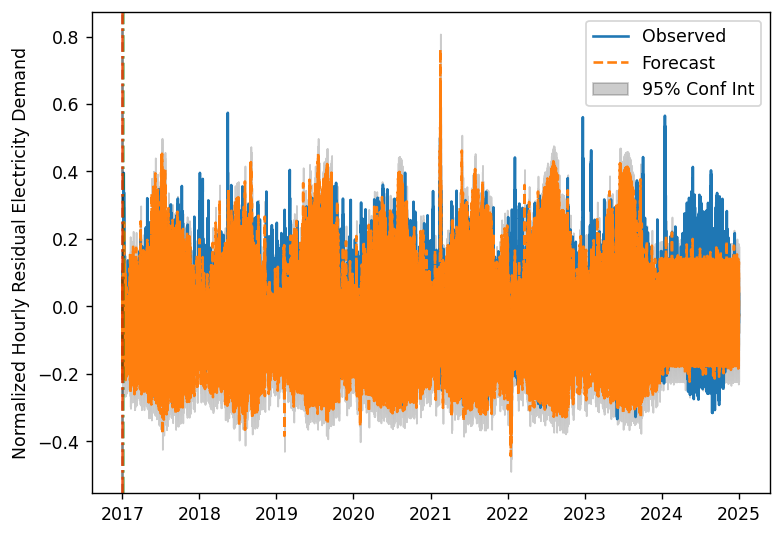

In [98]:
ForecastingHelpers.plot_full_w_div(yp_te, pred_mapie_te, yp_te.index, pred_ci_te, div)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")

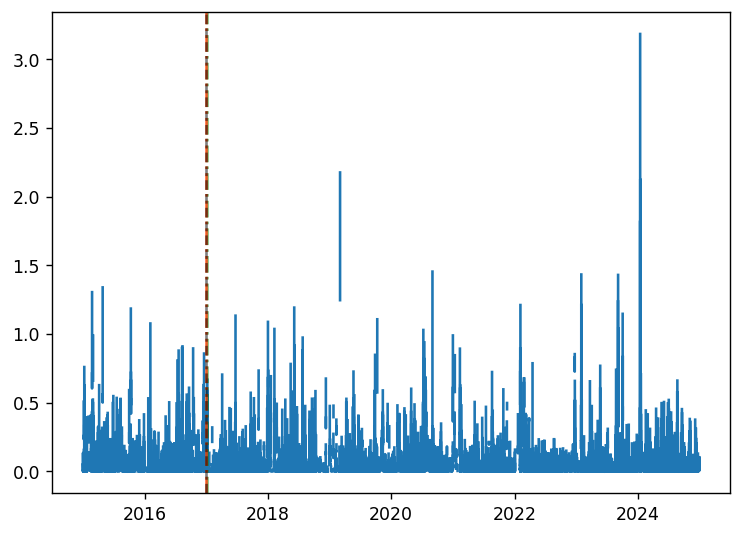

In [99]:
plt.plot(diverge)
plt.axvline(x=low_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=med_drift, color="orange", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--")